对称矩阵的特征值分解
S = 
 [[5 2]
 [2 4]]
S 是对称的吗？ True

特征值: [2.43844719 6.56155281]
特征向量 (正交):
[[ 0.61541221 -0.78820544]
 [-0.78820544 -0.61541221]]

特征向量点积: 0.000000 (应为0)

正定矩阵检查
✅ S 是正定矩阵！
   1. 所有特征值 > 0
   2. 对于任何 x ≠ 0，x^T S x > 0
   3. 能量函数是凸的，有唯一最小值


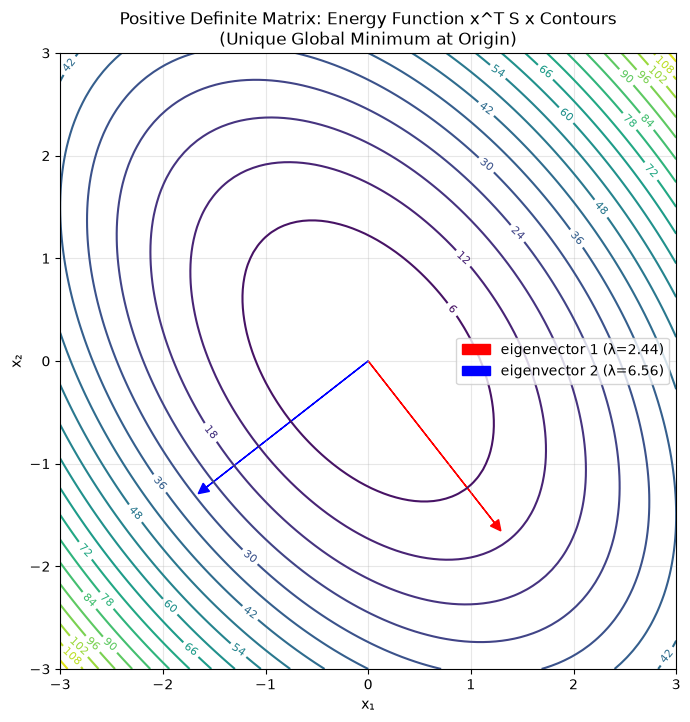


非正定矩阵的特征值与特征向量
B = 
 [[1 2]
 [2 1]]
特征值: [-1.  3.]
特征向量:
[[-0.70710678  0.70710678]
 [ 0.70710678  0.70710678]]


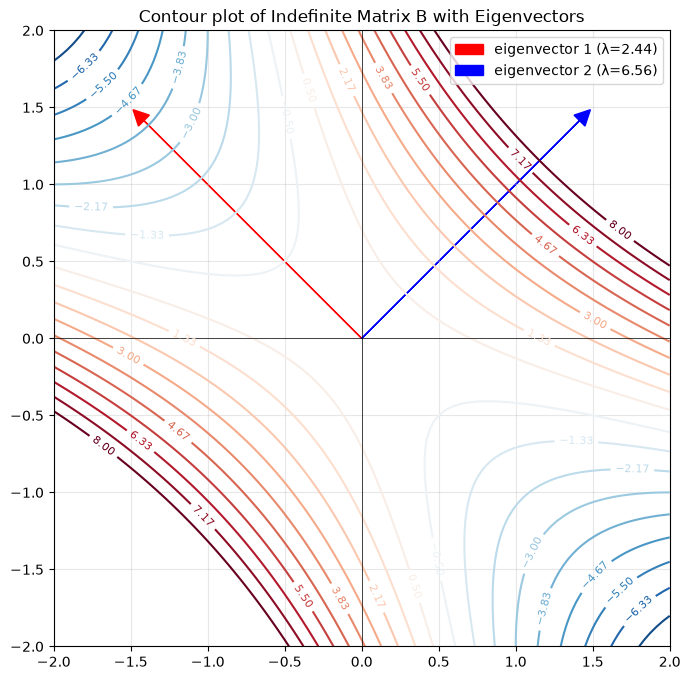

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# ---- 创建一个对称矩阵 ----
S = np.array([[5, 2], [2, 4]])

print("=" * 60)
print("对称矩阵的特征值分解")
print("=" * 60)
print("S = \n", S)
print(f"S 是对称的吗？ {np.allclose(S, S.T)}")

# ---- 特征值分解 ----
eigenvalues, eigenvectors = np.linalg.eigh(S)  # 对对称矩阵用 eigh 更稳定
print(f"\n特征值: {eigenvalues}")
print(f"特征向量 (正交):\n{eigenvectors}")

# ---- 验证特征向量正交 ----
print(f"\n特征向量点积: {np.dot(eigenvectors[:, 0], eigenvectors[:, 1]):.6f} (应为0)")

# ---- 正定检查 ----
print("\n" + "=" * 60)
print("正定矩阵检查")
print("=" * 60)
if np.all(eigenvalues > 0):
    print("✅ S 是正定矩阵！")
    print("   1. 所有特征值 > 0")
    print("   2. 对于任何 x ≠ 0，x^T S x > 0")
    print("   3. 能量函数是凸的，有唯一最小值")
else:
    print("❌ S 不是正定矩阵")

# ---- 可视化：正定矩阵的“碗” ----
# 绘制能量函数 f(x) = x^T S x 的等高线
x = np.linspace(-3, 3, 100)
y = np.linspace(-3, 3, 100)
X_grid, Y_grid = np.meshgrid(x, y)

# 计算 x^T S x
Z = np.zeros_like(X_grid)
for i in range(X_grid.shape[0]):
    for j in range(X_grid.shape[1]):
        v = np.array([X_grid[i, j], Y_grid[i, j]])
        Z[i, j] = v.T @ S @ v

plt.figure(figsize=(10, 8))
contour = plt.contour(X_grid, Y_grid, Z, levels=20, cmap='viridis')
plt.clabel(contour, inline=True, fontsize=8)

# 画特征向量方向
for i in range(len(eigenvalues)):
    v = eigenvectors[:, i] * 2
    plt.arrow(0, 0, v[0], v[1], 
             head_width=0.1, head_length=0.1,
             fc='red' if i==0 else 'blue',
             ec='red' if i==0 else 'blue',
             label=f'eigenvector {i+1} (λ={eigenvalues[i]:.2f})')

plt.xlabel('x₁')
plt.ylabel('x₂')
# plt.title('正定矩阵的能量函数 x^T S x 的等高线\n（最小值在原点，唯一全局最优）')
plt.title('Positive Definite Matrix: Energy Function x^T S x Contours\n(Unique Global Minimum at Origin)')
plt.legend()
plt.grid(alpha=0.3)
plt.gca().set_aspect('equal')
plt.show()

# ---- 非正定矩阵的等高线与特征向量 ----
B = np.array([[1, 2], [2, 1]])
eigenvalues_B, eigenvectors_B = np.linalg.eigh(B)

print("\n============================================================")
print("非正定矩阵的特征值与特征向量")
print("============================================================")
print("B = \n", B)
print(f"特征值: {eigenvalues_B}")
print(f"特征向量:\n{eigenvectors_B}")

# 生成网格
x = np.linspace(-2, 2, 100)
y = np.linspace(-2, 2, 100)
X, Y = np.meshgrid(x, y)

# 计算二次型 z = [x, y] B [x, y]^T
Z = B[0, 0]*X**2 + (B[0, 1] + B[1, 0])*X*Y + B[1, 1]*Y**2

plt.figure(figsize=(8, 8))
# 绘制等高线，非正定矩阵的等高线为双曲线，指定正负level以展示鞍点形状
levels = np.concatenate([np.linspace(-8, -0.5, 10), np.linspace(0.5, 8, 10)])
contour = plt.contour(X, Y, Z, levels=levels, cmap='RdBu_r')
plt.clabel(contour, inline=True, fontsize=8)

# 绘制特征向量
# for i in range(len(eigenvalues_B)):
#     v = eigenvectors_B[:, i].real
#     # 使用 quiver 绘制向量箭头
#     plt.quiver(0, 0, v[0], v[1], angles='xy', scale_units='xy', scale=1, 
#                color=['red', 'blue'][i], width=0.02, 
#                label=f'v_{i+1} (λ={eigenvalues_B[i]:.2f})')
for i in range(len(eigenvalues)):
    v = eigenvectors_B[:, i] * 2
    plt.arrow(0, 0, v[0], v[1], 
             head_width=0.1, head_length=0.1,
             fc='red' if i==0 else 'blue',
             ec='red' if i==0 else 'blue',
             label=f'eigenvector {i+1} (λ={eigenvalues[i]:.2f})')

plt.axhline(0, color='black', linewidth=0.5)
plt.axvline(0, color='black', linewidth=0.5)
plt.xlim(-2, 2)
plt.ylim(-2, 2)
plt.grid(alpha=0.3)
plt.title('Contour plot of Indefinite Matrix B with Eigenvectors')
plt.legend()
plt.gca().set_aspect('equal')
plt.show()